In [ ]:
import numpy as np
import scipy.special as sp
from  scipy.constants import c
import matplotlib.pyplot as plt

#!pip install OptiCommPy
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
from optic.models.devices import mzm, photodiode

## Fibra Óptica
---

## Sumário
---
- [Introdução](#introdução)
- [Equação Característica](#equação-caracteristica)
- [Intensidade de campo](#intensidade-de-campo)

### Introdução
---

#### Equação de Sellmeier
A equação de Sellmeier descreve matematicamente a variação do índice de refração $n$ de um material transparente em função do comprimento de onda da luz. Em sua forma mais comum, essa equação é escrita como:

$$\begin{equation}
n^2(\omega) = 1\ + \
\sum_{j=1}^{m}\frac{B_j\omega_j^2}{\omega_j^2-\omega^2}
\end{equation},$$

#### Funções de Bessel

As funções de Bessel de primeira espécie $J_n(x)$ surgem com frequência em contextos de modulação óptica, especialmente quando há modulação senoidal ou de fase, como nos moduladores de Mach-Zehnder (MZM) operando em regime não linear. Ela é a solução da seguinte equação diferencial.

$$\begin{equation}
x^2\frac{d^2y}{dx^2} \ + \ x \frac{dy}{dx} \ + \
(x^2 - p^2) y \ = \ 0
\end{equation}$$

__Importância para as comunicações ópticas:__
- Ao modular um sinal óptico com um MZM em regime senoidal, surgem vários harmônicos no espectro, cujas amplitudes são determinadas por funções de Bessel.

- Isso permite prever o número de sidebands (faixas laterais) e sua intensidade relativa, definindo a largura de banda efetiva do sinal.

- Essencial para sistemas com modulação de fase (PM) ou modulação de frequência (FM), bem como para o dimensionamento de filtros ópticos e canais WDM.

- Também é usada para analisar o comportamento de moduladores sob diferentes profundidades de modulação.

Em resumo, as funções de Bessel fornecem a base matemática para entender como a modulação afeta o espectro óptico e como controlar a geração de harmônicos e sidebands, o que impacta diretamente a eficiência espectral e a capacidade do sistema.


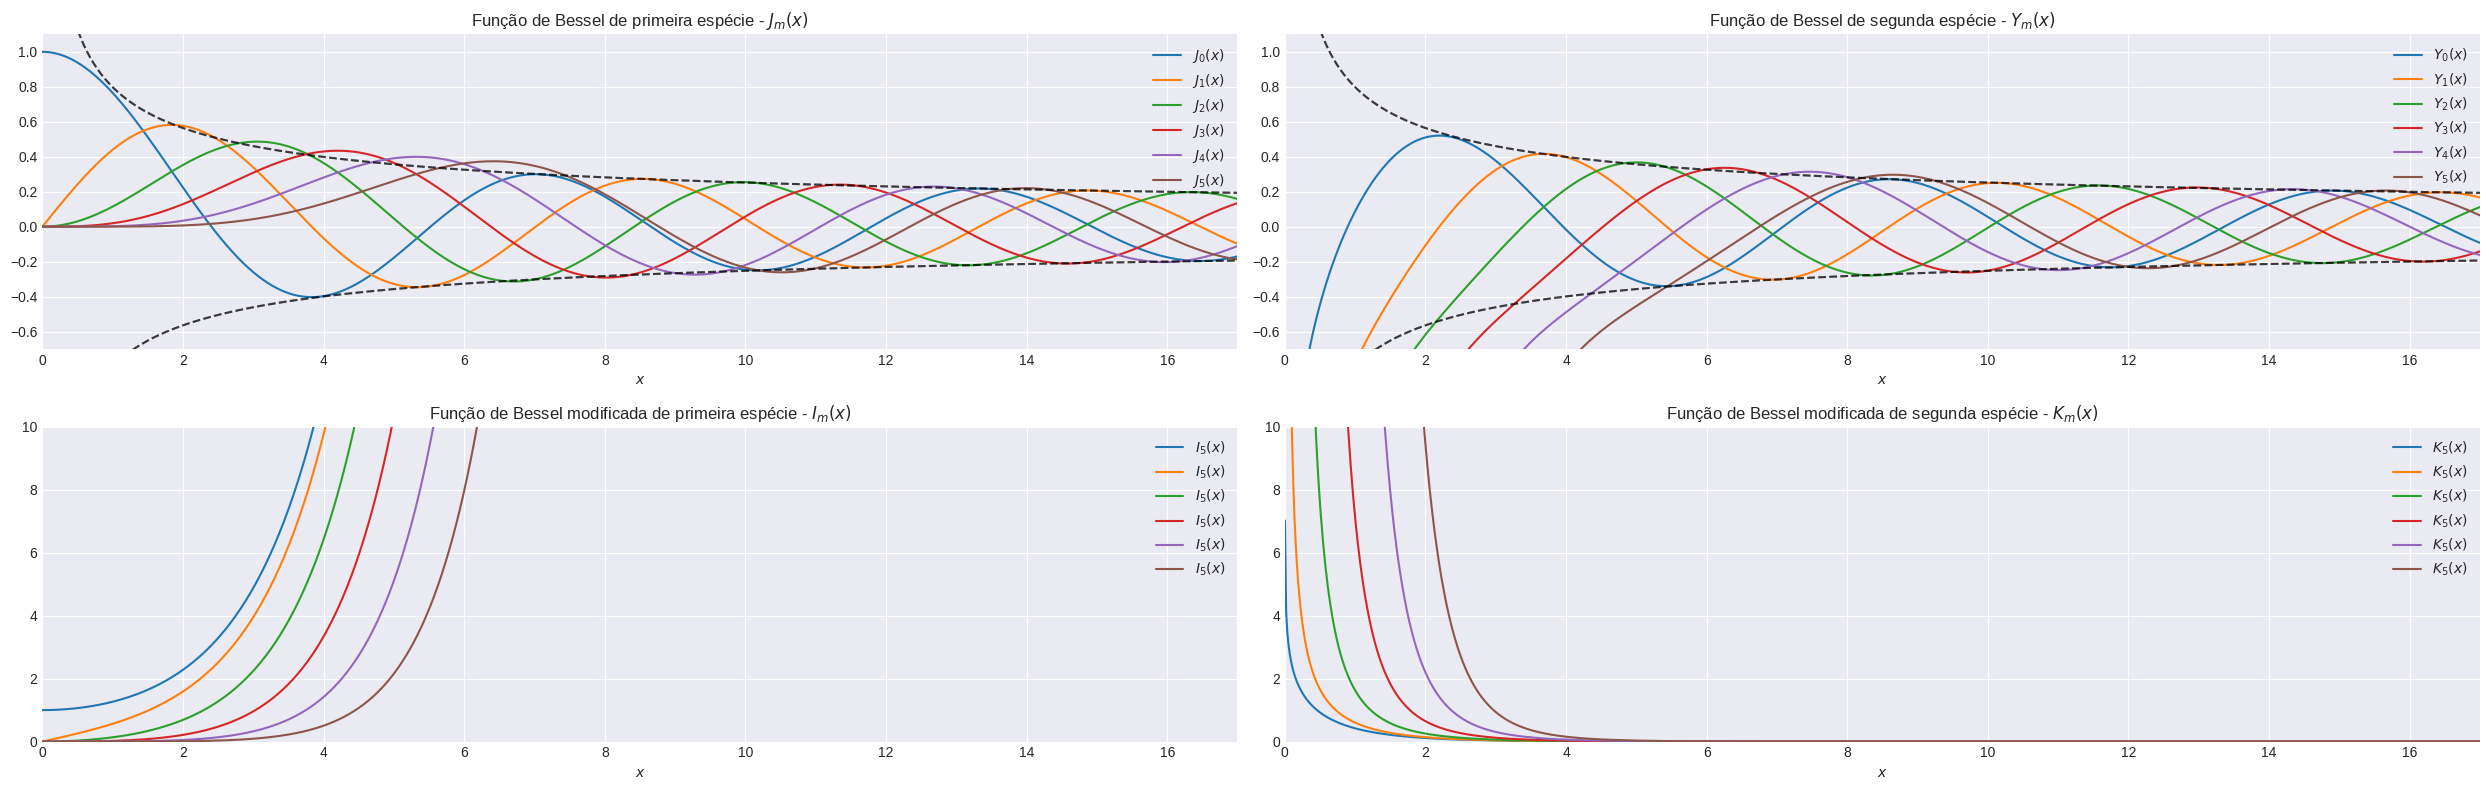

In [ ]:
#Crinado valores aleatórios para o eixo x.
x = np.linspace(0.001, 17, 1000)

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(25, 8))

for m in range(0, 6):
    axes[0,0].plot(x, sp.jv(m, x), label=f"$J_{m}(x)$")
axes[0,0].set_title("Função de Bessel de primeira espécie - ${J}_m(x)$", fontsize = 12)

for m in range(0, 6):
  axes[0,1].plot(x, sp.yv(m, x), label=f"$Y_{m}(x)$")
axes[0,1].set_title("Função de Bessel de segunda espécie - ${Y}_m(x)$", fontsize = 12)

for v in range(0, 6):
  axes[1,0].plot(x, sp.iv(v, x), label=f"$I_{m}(x)$")
axes[1,0].set_title("Função de Bessel modificada de primeira espécie - ${I}_m(x)$", fontsize = 12)

for v in range(0, 6):
  axes[1,1].plot(x, sp.kv(v, x), label=f"$K_{m}(x)$")
axes[1,1].set_title("Função de Bessel modificada de segunda espécie - ${K}_m(x)$", fontsize = 12)

for n in range(0, 2):
  for m in range(0, 2):
    axes[n,m].set_xlim((0, 17))
    axes[n,m].set_ylim((-0.7, 1.1))
    axes[n,m].set_xlabel("$x$")
    axes[n,m].legend(loc = "upper right")

  # Envelopes superior e inferior
    limite = np.sqrt(2 / (np.pi * x))
    axes[0,m].plot(x, limite, "k--", alpha = 0.5)
    axes[0,m].plot(x,-limite, "k--", alpha = 0.5)
    if n == 1: axes[n,m].set_ylim((0, 10))

plt.tight_layout()
plt.show()

### Equação característica
---
A equação característica da fibra óptica pode ser definida e dividindo em três partes temos:

$$\begin{equation}
\underbrace{\left[
\frac{J'_m(pa)}{pJ_m(pa)} + \frac{K'_m(qa)}{qK_m(qa)}
\right]}_{LHS_1} \ \
\underbrace{\left[
\frac{J'_m(pa)}{pJ_m(pa)} + \frac{n_2^2}{n_1^2} \frac{K'_m(qa)}{qK_m(qa)}
\right]}_{LHS_2} \ \ = \ \
\underbrace{
\left(\frac{m}{a}\right)^2
\left(\frac{1}{p^2} + \frac{1}{q^2}\right)
\left(\frac{1}{p^2} + \frac{n_2^2}{n_1^2}\frac{1}{p^2}\right)
}_{RHS}\end{equation}$$

>Essa equação vem do estudo das soluções do campo eletromagnético em coordenadas cilíndricas $(r, ϕ, z)$ para fibras ópticas.
  - Dentro da fibra (núcleo), a solução das equações diferenciais é feita usando as *funções de Bessel de primeira espécie:* $J_m$.
  - Fora da fibra (casca), como os campos devem decair, são usadas *funções de Bessel modificadas de segunda espécie:* $K_m$.

Onde temos as seguintes notações:
- __a__: é o raio do núcleo da fibra;
- __m__: é a ordem da função de Bessel;
- __$p^2$__ $= (n_1k_0)^2 - β^2$: parâmetro de propagação radial no núcleo;
- __$q^2$__ $= β^2 - (n_2k_0)^2$: parâmetro de decaimento na casca;
- __$n_1,n_2$__: índices de refração do núcleo e da casca;
-__β__ $= n_{eff}k_0$: constante de propagação longitudinal;
- __$n_{eff}$__: é o índice de refração efetivo que varia entre $n_2\ e\ n_1$.

In [ ]:
# Parametro físico da fibra.
a    = 4.5e-6                # raio do núcleo da fibra
n1   = 1.448918              # índice do núcleo
n2   = 1.444418              # índice da casca
NA   = np.sqrt(n1**2-n2**2)  # abertura numérica
lmbd = 1550e-9               # comprimento de onda de operação
k0   = 2*np.pi/lmbd          # número de onda no espaço livre
V    = a*k0*NA               # frequência de operação normalizada

V_cutoff = 2.405
a_cutoff = V_cutoff/(k0*NA)

lmbd_cutoff = (a*NA*2*np.pi)/V_cutoff

print("(n2/n1)^2 = %4.3f" % ((n2/n1)**2))
print("V = %4.2f" %(V))
print('\nRaio [m] máximo para condição monomodo: %3.2e' %(a_cutoff))
print('\nComprimento de onda [m] mínimo para condição monomodo: %4.3e' %(lmbd_cutoff))

(n2/n1)^2 = 0.994
V = 2.08

Raio [m] máximo para condição monomodo: 5.20e-06

Comprimento de onda [m] mínimo para condição monomodo: 1.341e-06


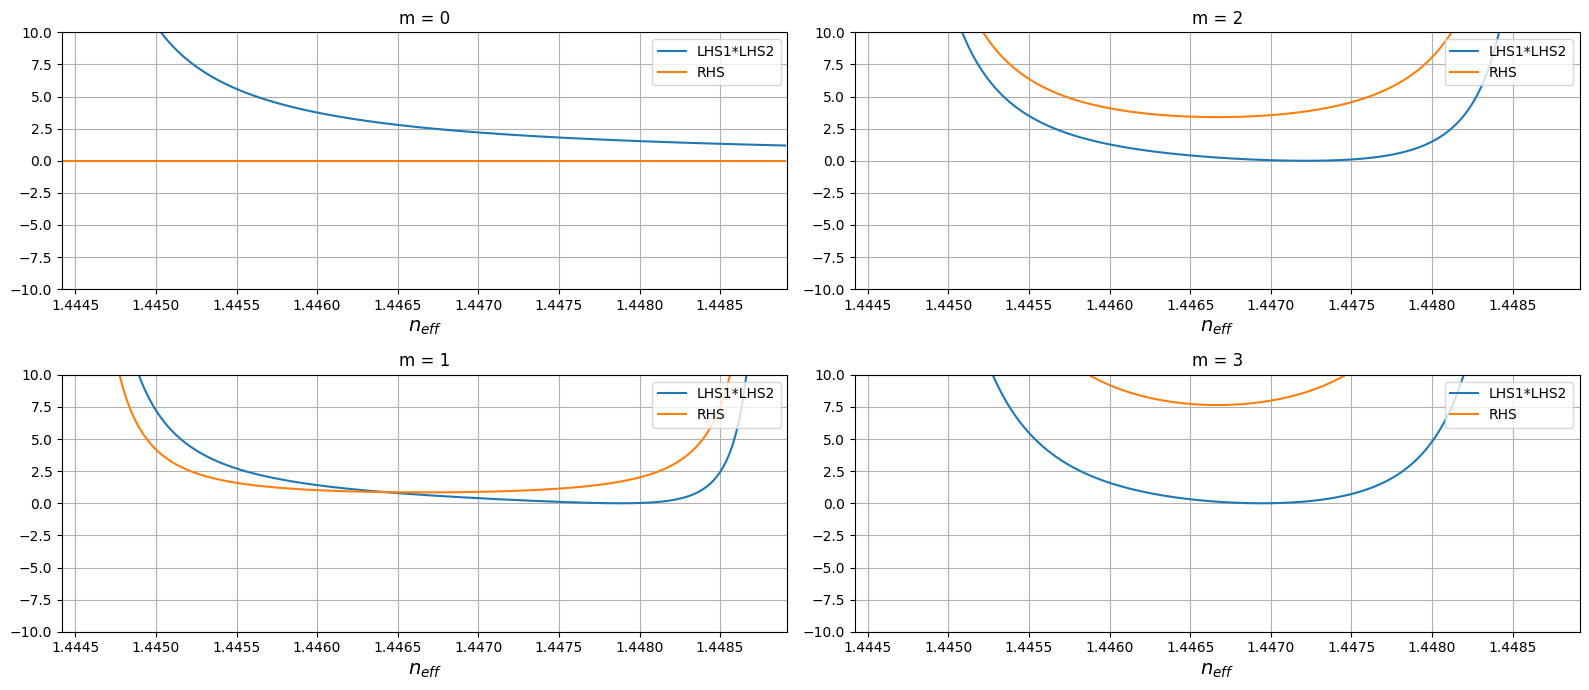

In [ ]:
neff = np.linspace(n2*1.00001, n1*0.99999, 1000)
beta = neff*k0
p = np.sqrt((n1*k0)**2-beta**2)
q = np.sqrt(beta**2-(n2*k0)**2)

fc = (n2/n1)**2
fig, ax = plt.subplots(2,2,figsize=(16,7))
for m in range(4):
  # Cálculo das funções
  LHS1 = 1/a*(sp.jvp(m, p*a)/(p*sp.jv(m, p*a)) + sp.kvp(m, q*a)/(q*sp.kv(m,q*a)))
  LHS2 = 1/a*(sp.jvp(m, p*a)/(p*sp.jv(m, p*a)) + sp.kvp(m, q*a)/(q*sp.kv(m,q*a)*fc))
  RHS  = 1/a**2 * ((m/a)**2)*(1/(p**2)+1/(q**2))*(1/(p**2)+fc/(q**2))
  # Elimina as discontinuidades
  LHS1[:-1][np.diff(LHS1) < -7] = np.nan
  LHS2[:-1][np.diff(LHS2) < -7] = np.nan
  # Plota as funções
  ax[np.mod(m,2),int(m>1)].plot(neff, LHS1*LHS2, label = "LHS1*LHS2")
  ax[np.mod(m,2),int(m>1)].plot(neff, RHS, label = "RHS")
  ax[np.mod(m,2),int(m>1)].set_xlabel(r'$n_{eff}$', fontsize = 14)
  ax[np.mod(m,2),int(m>1)].set_title('m = %d' %(m))
  ax[np.mod(m,2),int(m>1)].set_xlim([n2, n1])
  ax[np.mod(m,2),int(m>1)].set_ylim([-10,10])
  ax[np.mod(m,2),int(m>1)].grid(True)
  ax[np.mod(m,2),int(m>1)].legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Conclusão

Os estudos realizados foram de grande importância para compreender o funcionamento das fibras ópticas, especialmente no que diz respeito à distinção entre fibras monomodo e multimodo. Foi possível entender como determinar os parâmetros físicos da fibra, como o raio do núcleo e o comprimento de onda de operação, que influenciam diretamente na condição de propagação dos modos.

A equação de dispersão modal, baseada nas funções de Bessel, mostrou-se essencial para representar com precisão o comportamento da luz no interior da fibra óptica. As funções de Bessel, por sua natureza, descrevem adequadamente as soluções das equações de Maxwell em coordenadas cilíndricas, sendo amplamente utilizadas para modelar modos guiados.

Através da implementação e análise dos códigos, conseguimos visualizar graficamente o regime monomodo da fibra e identificar os valores de índice efetivo $n_{eff}$ que satisfazem a condição de existência de um modo. Observamos que apenas o modo HE₁₁ (com $m=1$) é suportado, confirmando o funcionamento em regime monomodo, e compreendemos como a igualdade entre as curvas $LHS1 * LHS2$ e $RHS$ representa a solução da equação de dispersão. Dessa forma, o estudo teórico aliado à simulação computacional proporcionou uma visão mais clara e fundamentada sobre a propagação modal em fibras ópticas.


### Intensidade do campo
---

Essa equação implementa a solução analítica do campo de um modo guiado em fibra de índice degrau, o que é essencial para entender, projetar e otimizar fibras ópticas, tanto em simulações como na análise teórica.

$$\begin{equation}
E_z(p,m,z) = A \begin{cases}J_m(pp)e^{imØ}e^{iβz},\ \ \ \text{$p\leq a$}\\
\frac{J_m(pa)}{K_m(qa)}K_m(qp)e^{imØ}e^{iβz}, \ \ \ \text{$p \gt a$}
\end{cases}\end{equation}$$

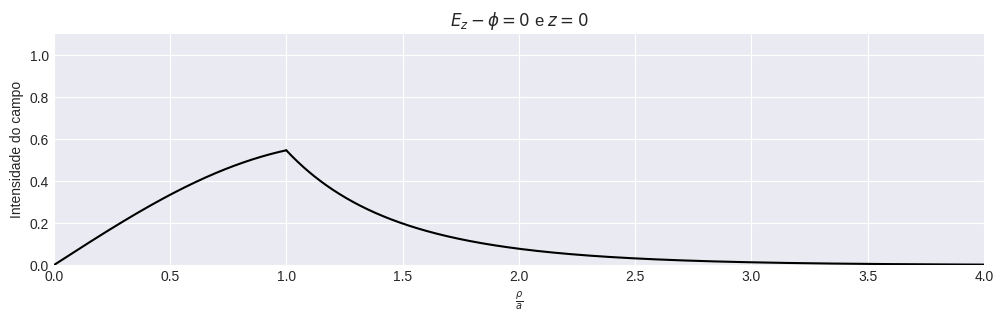

In [ ]:
def ez_field(x, f, z, order, pf, qf, radius):
  if x[0] < radius:
    return sp.jv(order, pf*x)
  else:
    return (sp.jv(order, pf*radius)/sp.kv(order, qf*radius))*sp.kv(order, qf*x)

neff_0 = 1.4468
m = 1
beta_0 = neff_0*k0
p_0 = np.sqrt((n1*k0)**2-beta_0**2)
q_0 = np.sqrt(beta_0**2-(n2*k0)**2)
rho1 = np.linspace(0,a,1000)
rho2 = np.linspace(a,4*a,1000)
Ez1_0 = ez_field(rho1, 0, 0, m, p_0, q_0, a)
Ez2_0 = ez_field(rho2, 0, 0, m, p_0, q_0, a)

plt.figure(figsize=(12,3))
plt.style.use("seaborn-v0_8-darkgrid")
plt.plot(rho1/a, Ez1_0, "k")
plt.plot(rho2/a, Ez2_0, "k")
plt.xlabel(r"$\frac{\rho}{a}$")
plt.xlim([0,4])
plt.ylabel("Intensidade do campo")
plt.title(r"$E_z - \phi = 0$ e $z = 0$")
plt.ylim([0,1.1])
plt.show()

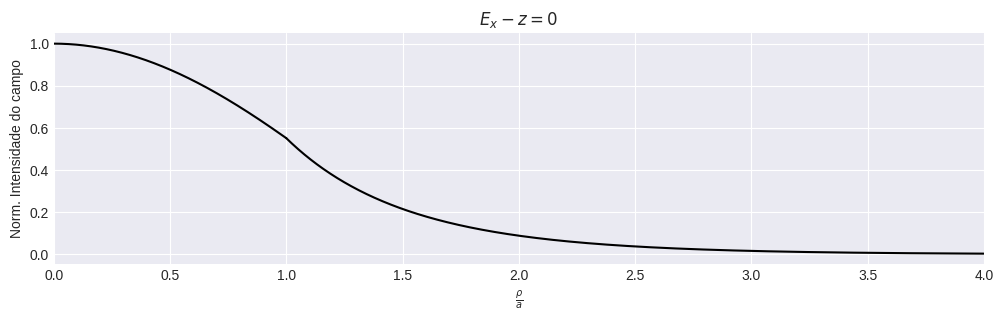

In [ ]:
def ex_field_HE11(x, pf, qf, beta, z, radius):
  if x.flatten()[0] < radius:       # x representa o rho da equação abaixo. Flatten deixa o vetor em unica
    return sp.jv(0, pf*x)/sp.jv(0, pf*radius)*np.real(np.exp(1j*beta*z))
  else:
    return sp.kv(0, qf*x)/sp.kv(0, qf*radius)*np.real(np.exp(1j*beta*z))

plt.figure(figsize=(12,3))
Ex1_2D = ex_field_HE11(rho1, p_0, q_0, beta_0, 0, a)
Ex2_2D = ex_field_HE11(rho2, p_0, q_0, beta_0, 0, a)
maxExField = np.max(Ex1_2D)
plt.plot(rho1/a, Ex1_2D/maxExField, "k")
plt.plot(rho2/a, Ex2_2D/maxExField, "k")
plt.xlabel(r"$\frac{\rho}{a}$")
plt.xlim([0,4])
plt.ylabel("Norm. Intensidade do campo")
plt.title(r"$E_x - z = 0$")
plt.show()

Outra análise importante é sobre o modo fundamental como vimos acima, no qual as componentes longitudinais $E_z$  e $H_z$ são muito menores do que as componentes transversais. Isso ocorre nas chamadas fibras de fraco guiamento, em que o modo *HE₁₁* pode ser aproximado por um modo linearmente polarizado, conhecido como modo *LP₀₁*.

Nessa aproximação, considera-se que o campo está polarizado ao longo de um dos eixos transversais (por exemplo, o eixo x), e que a componente ortogonal é desprezível (por exemplo, $E_y=0$). Assim, a principal componente do campo elétrico passa a ser $E_x$ , que pode ser expressa por:

$$\begin{equation}
E_x(ρ,m,z) = E_0\begin{cases}
\frac{J_0(pρ)}{J_0(pa)}e^{iβz} , \ ρ \leq a \\
\frac{K_0(qρ)}{K_0(qa)}e^{iβz} , \ ρ \gt a
\end{cases}\end{equation}$$

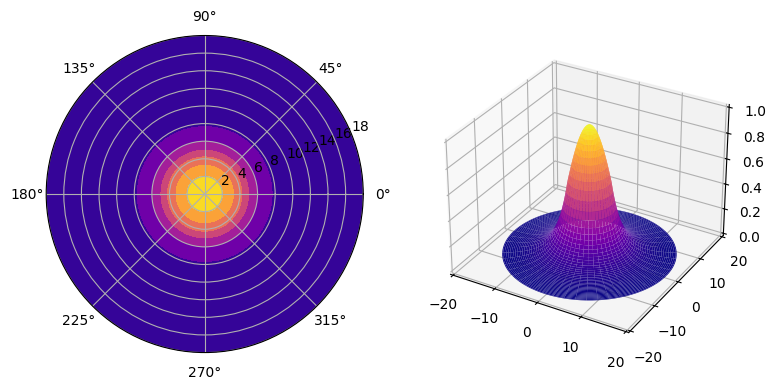

In [ ]:
import matplotlib.cm as cm

def ex_field_HE11(x, pf, qf, beta, z, radius):
  Z = np.zeros(np.shape(x))
  idxLow  = (x < radius)
  idxHigh = (x >= radius)
  Z[idxLow]  = sp.jv(0, pf*x[idxLow])/sp.jv(0, pf*radius)*np.real(np.exp(1j*beta*z))
  Z[idxHigh] = sp.kv(0, qf*x[idxHigh])/sp.kv(0, qf*radius)*np.real(np.exp(1j*beta*z))
  return Z

r = np.linspace(0, 4*a, 100)
theta  = np.linspace(0, 2*np.pi, 100)
R, THETA = np.meshgrid(r, theta)
X, Y = R*np.cos(THETA), R*np.sin(THETA)
Ex_HE11_P = ex_field_HE11(R, p_0, q_0, beta_0, 0, a)
maxEx_HE11_P = np.max(Ex_HE11_P)

fig = plt.figure(figsize=(9,6))
plt.style.use("default")
ax1 = fig.add_subplot(121,projection="polar")
ax1.contourf(THETA, 1e6*R, Ex_HE11_P/maxEx_HE11_P, cmap=plt.cm.plasma)
ax2 = fig.add_subplot(122,projection="3d")
ax2.plot_surface(1e6*X, 1e6*Y, Ex_HE11_P/maxEx_HE11_P, cmap=plt.cm.plasma)
plt.show()

### Referências
---
1. **OpticalCommunications**. *Edson porto da Silva*. Disponível em: [https://github.com/edsonportosilva/OpticalCommunications/...notebooks](https://github.com/edsonportosilva/OpticalCommunications/tree/main/jupyter%20notebooks). Acessado em: 05 de maio de 2025.
2. **Função de Bessel**.*Wikipédia*. Disponível em: [wikipedia.org/..._Bessel](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_de_Bessel). Acessado em: 05 de maio de 2025.
3. **Documentação Numpy**.*Numpy*. Disponível em: [https://numpy.org/doc/2.2/index.html](https://numpy.org/doc/2.2/index.html).  Acessado em:19 de maio de 2025.